# Initialize

In [1]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np

import glori.settings.paths as paths

from glori.plotting.images import plot_image_grid

In [25]:
mm = 1 / 25.4  # mm in inches
fig_width = 90 * mm
# plt.rcParams.update({"font.size": 5})
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "figure.constrained_layout.use": True,
        "figure.dpi": 150,
        "font.family": "Nimbus Roman",
        "font.size": 4.5,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Nimbus Roman",
        "mathtext.it": "Nimbus Roman:italic",
        "mathtext.bf": "Nimbus Roman:bold",
        "mathtext.cal": "Nimbus Roman:italic",
        "text.usetex": False,
        "legend.frameon": False,
    }
)

color_samples = plt.get_cmap("viridis")(0.1)
color_original = plt.get_cmap("viridis")(0.75)


# Output settings
output_parent = paths.ANALYSIS_PARENT / "paper_plots_III"
savefig_kw = dict(dpi=200, bbox_inches="tight", pad_inches=1e-2)

out_path_sub = output_parent / "review_1"
out_path_sub.mkdir(parents=True, exist_ok=True)

artifacts_parent = paths.ANALYSIS_PARENT / 'paper_plots_III_artifacts'
artifacts_parent.mkdir(parents=True, exist_ok=True)

In [3]:
from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

# Load run result

In [20]:
from glori.analysis.ldm.io import load_sampling_result

run_name = "fat-interval"

res = load_sampling_result(run_name)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
original_imgs = original_imgs.reshape(-1, *original_imgs.shape[-2:])
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

sampled_imgs_unscaled = scaler.inverse_scale(sampled_imgs)

 11:32:02 (glori.analysis.ldm.io) - INFO : Loading results for <fat-interval>...
Loading original BDSF results: 100%|██████████| 64/64 [00:01<00:00, 44.32it/s]
 11:32:06 (glori.analysis.ldm.io) - INFO : Done.


In [21]:
resid_maps = np.array([r["resid_gaus_arr"] for r in res["bdsf_results"]])
resid_maps_original = np.array([r["resid_gaus_arr"] for r in res["orig_bdsf_results"]])
rms = np.sqrt(np.nanmean(resid_maps**2, axis=(-2, -1)))

In [22]:
from glori.data.obs.micromaps.utils import fill_nan_pixels

original_imgs = np.array([fill_nan_pixels(img) for img in original_imgs])

nan_flag = np.isnan(original_imgs).any(axis=(-2, -1))

In [23]:
n_sources = (ctxt[:, 0] > 0).sum(axis=(-2, -1))
np.mean(n_sources), np.median(n_sources), np.max(n_sources), np.min(n_sources), np.std(
    n_sources
)

(309.453125, 269.0, 870, 8, 176.4601521668118)

(array([ 5., 11., 14., 10., 10.,  7.,  3.,  2.,  1.,  1.]),
 array([  2.  ,  23.55,  45.1 ,  66.65,  88.2 , 109.75, 131.3 , 152.85,
        174.4 , 195.95, 217.5 ]),
 <BarContainer object of 10 artists>)

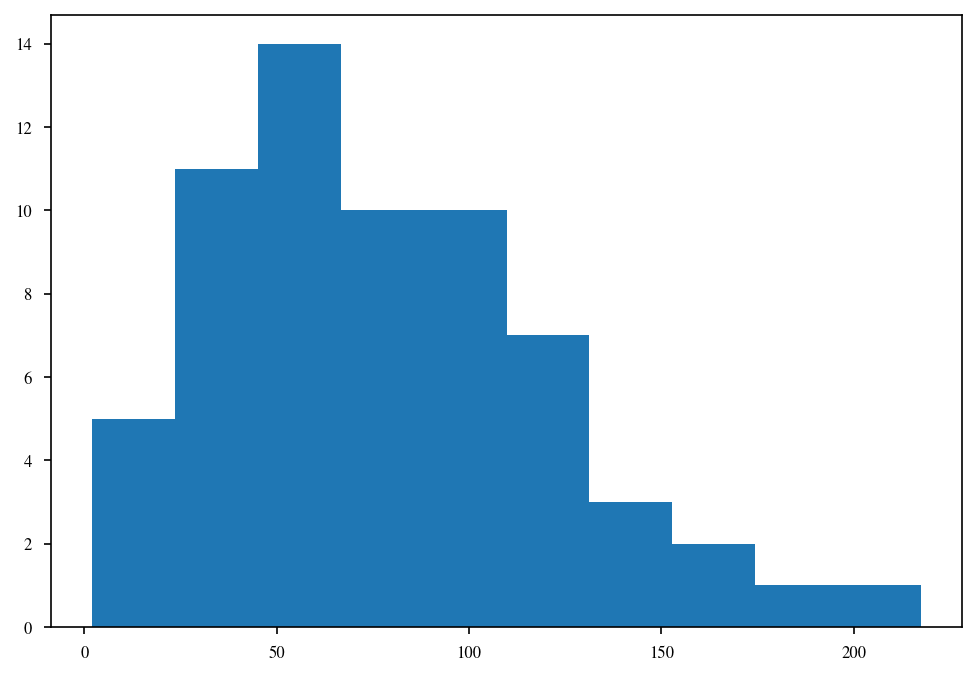

In [24]:
plt.hist(n_sources / 4)

# Source matching:

In [9]:
import glori.analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

 11:24:41 (ldm-match) - INFO : Extracting data from resample result...
 11:24:41 (ldm-match) - INFO : Matching sources...
100%|██████████| 64/64 [00:05<00:00, 11.37it/s]
 11:24:47 (ldm-match) - INFO : Concatenating matched data...
 11:24:47 (ldm-match) - INFO : Done matching sources.

              Total input sources:	19805
             Total output sources:	18325
            Total matched sources:	16314
    Total unmatched input sources:	3491
   Total unmatched output sources:	1824



# Power spectrum & RMS

## Power Spectrum

### Functions:

In [10]:
import numpy as np
from scipy.ndimage import label


def fill_nan_pixels_batch(images, max_size=8, early_stop=True):
    """
    Fill NaN pixels in small islands with mean of their 8-connectivity neighbors,
    independently per image in a batch.

    Parameters:
        images: (B, H, W) array, may contain NaNs
        max_size: Maximum size of NaN island to fill (per image)
        early_stop: if True, stop processing entirely once an island exceeds
                    max_size (same behavior as the original function -- note
                    this means islands appearing later in label order are
                    skipped too, even if small; preserved here for consistency)

    Returns:
        filled_images: (B, H, W) array with small NaN islands filled
    """
    filled = images.copy()
    nan_mask = np.isnan(filled)
    if not nan_mask.any():
        return filled

    # 3x3x3 structure, but only the middle layer (batch offset 0) is connected --
    # this blocks connectivity across the batch axis, so islands can never
    # span two different images even though we label the whole (B,H,W) volume at once
    structure = np.zeros((3, 3, 3), dtype=bool)
    structure[1] = True  # full 8-connectivity within a single image's H,W plane

    island_labels, num_labels = label(nan_mask, structure=structure)
    island_sizes = np.bincount(island_labels.ravel())[1:]  # skip background 0

    H, W = filled.shape[1:]

    for island_id, size in enumerate(island_sizes, start=1):
        if size > max_size:
            if early_stop:
                break
            continue

        b_idx, y_idx, x_idx = np.where(island_labels == island_id)

        for b, y, x in zip(b_idx, y_idx, x_idx):
            y_start, y_end = max(0, y - 1), min(H, y + 2)
            x_start, x_end = max(0, x - 1), min(W, x + 2)
            neighborhood = filled[b, y_start:y_end, x_start:x_end]

            valid_mask = ~np.isnan(neighborhood)
            valid_mask[y - y_start, x - x_start] = False

            if valid_mask.sum():
                filled[b, y, x] = neighborhood[valid_mask].mean()

    return filled


def power_spectrum_2d(images):
    """
    images: (..., H, W) array, batch dims leading
    returns: (..., H, W) power spectrum
    """
    fft = np.fft.fft2(images, axes=(-2, -1))
    fft_shifted = np.fft.fftshift(fft, axes=(-2, -1))
    power = np.abs(fft_shifted) ** 2
    return power


def autocorrelation_2d(images, normalize_coef=True, fill_nan=False):
    """
    images: (..., H, W)
    returns: (..., H, W) real-space autocorrelation, zero-lag at center
    normalize_coef: divide by zero-lag value -> coefficient in [-1, 1]
    """
    if fill_nan:
        images = fill_nan_pixels_batch(images)

    images = images - images.mean(axis=(-2, -1), keepdims=True)  # remove DC per image

    fft = np.fft.fft2(images, axes=(-2, -1))
    power = np.abs(fft) ** 2
    acf = np.fft.ifft2(power, axes=(-2, -1)).real
    acf = np.fft.fftshift(acf, axes=(-2, -1))  # zero-lag now at center

    if normalize_coef:
        H, W = images.shape[-2:]
        center = acf[..., H // 2, W // 2]  # zero-lag value
        acf = acf / center[..., None, None]

    return acf


def linear_autocorr_profile(
    images, axis, normalize_counts=True, normalize_coef=True, fill_nan=False
):
    """
    Unwrapped, mean-subtracted, normalized autocorrelation along one axis.

    images: (..., H, W)
    axis: -1 (horizontal) or -2 (vertical)
    normalize_counts: divide by number of overlapping pairs at each lag
    normalize_coef: divide by zero-lag value -> coefficient in [-1, 1]

    returns: (..., L) array; index k = lag in pixels
    """
    if fill_nan:
        images = fill_nan_pixels_batch(images)

    images = images - images.mean(axis=(-2, -1), keepdims=True)  # remove DC per image

    L = images.shape[axis]
    n_fft = 2 * L

    fft = np.fft.fft(images, n=n_fft, axis=axis)
    power = np.abs(fft) ** 2
    acf = np.fft.ifft(power, axis=axis).real
    acf = np.take(acf, indices=np.arange(L), axis=axis)

    if normalize_counts:
        counts = L - np.arange(L)
        shape = [1] * acf.ndim
        shape[axis] = L
        acf = acf / counts.reshape(shape)

    other_axis = -1 if axis == -2 else -2
    profile = acf.mean(axis=other_axis)

    if normalize_coef:
        zero_lag = np.take(profile, indices=[0], axis=-1)
        profile = profile / zero_lag

    return profile


def horizontal_autocorr(images, **kwargs):
    return linear_autocorr_profile(images, axis=-1, **kwargs)


def vertical_autocorr(images, **kwargs):
    return linear_autocorr_profile(images, axis=-2, **kwargs)


def radial_profile_batched(power, center=None):
    """
    power: (B, H, W) array (or (H, W), handled as B=1)
    returns: (B, n_bins) radially averaged power spectrum
    """
    single = power.ndim == 2
    if single:
        power = power[None, ...]

    B, H, W = power.shape
    y, x = np.indices((H, W))
    if center is None:
        center = (H // 2, W // 2)
    r = np.sqrt((x - center[1]) ** 2 + (y - center[0]) ** 2).astype(int)
    n_bins = r.max() + 1

    # offset r by batch index so each batch's bins land in disjoint ranges
    r_flat = r.ravel()  # (H*W,)
    batch_offsets = (np.arange(B) * n_bins)[:, None]  # (B, 1)
    r_offset = r_flat[None, :] + batch_offsets  # (B, H*W)

    weights = power.reshape(B, -1)
    tbin = np.bincount(r_offset.ravel(), weights=weights.ravel(), minlength=B * n_bins)
    nr = np.bincount(r_offset.ravel(), minlength=B * n_bins)

    radial_mean = (tbin / nr).reshape(B, n_bins)

    return radial_mean[0] if single else radial_mean


def radial_profile(power, center=None):
    y, x = np.indices(power.shape)
    if center is None:
        center = (power.shape[0] // 2, power.shape[1] // 2)

    r = np.sqrt((x - center[1]) ** 2 + (y - center[0]) ** 2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), power.ravel())
    nr = np.bincount(r.ravel())
    radial_mean = tbin / nr

    return radial_mean


from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d


def find_spectrum_peaks(
    ps_1d, prominence=None, height=None, distance=None, log=True, smooth_size=None
):
    """
    ps_1d: (n_bins,) or (B, n_bins) radial power spectrum
    log: search in log-space (recommended -- prominence/height thresholds
         then become scale-invariant across orders of magnitude)
    smooth_size: if given, apply a uniform (boxcar) filter of this window size
                 before peak detection, to suppress spurious peaks from
                 high-k/low-mode-count noise. None = no smoothing.
    """
    single = ps_1d.ndim == 1
    if single:
        ps_1d = ps_1d[None, :]

    y = np.log10(np.clip(ps_1d, 1e-300, None)) if log else ps_1d.astype(float)

    if smooth_size is not None and smooth_size > 1:
        y = uniform_filter1d(y, size=smooth_size, axis=-1, mode="nearest")

    results = []
    for row in y:
        peaks, props = find_peaks(
            row, prominence=prominence, height=height, distance=distance
        )
        results.append((peaks, props))

    return results[0] if single else results

### Calculate & Plot:

In [ ]:
# acf = autocorrelation_2d(sampled_imgs_unscaled[~nan_flag])
# radial_acf = radial_profile_batched(acf)
# avg_radial_acf = radial_acf.mean(axis=0)

# acf_real = autocorrelation_2d(original_imgs[~nan_flag])
# radial_acf_real = radial_profile_batched(acf_real)
# avg_radial_acf_real = radial_acf_real.mean(axis=0)

In [11]:
xlim = -15, 30
bins = np.linspace(*xlim, 500)

counts_samples, _ = np.histogram(sampled_imgs[~nan_flag].ravel(), bins=bins)
counts_real, _ = np.histogram(scaler.scale(original_imgs[~nan_flag]).ravel(), bins=bins)

In [12]:
horiz_acf = horizontal_autocorr(sampled_imgs_unscaled[~nan_flag])
avg_horiz_acf = horiz_acf.mean(axis=0)
vert_acf = vertical_autocorr(sampled_imgs_unscaled[~nan_flag])
avg_vert_acf = vert_acf.mean(axis=0)

horiz_acf_real = horizontal_autocorr(original_imgs[~nan_flag])
avg_horiz_acf_real = horiz_acf_real.mean(axis=0)
vert_acf_real = vertical_autocorr(original_imgs[~nan_flag])
avg_vert_acf_real = vert_acf_real.mean(axis=0)

/tmp/ipykernel_2474620/1105367395.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(out_path_sub / "SWIIT_autocorrelation.png", **savefig_kw)


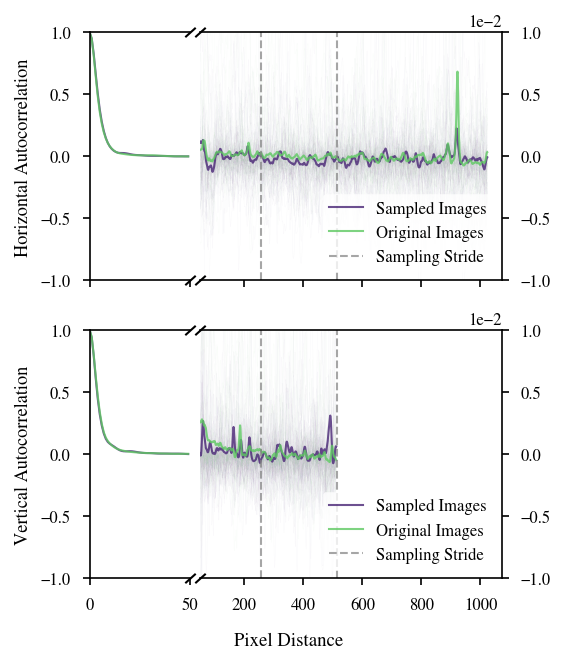

In [15]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(fig_width, fig_width * 4 / 3),
    sharex="col",
    sharey=False,  # <-- no longer sharing y between zoom/main
    gridspec_kw={"width_ratios": [1, 3], "wspace": 0.05},
    tight_layout=False,
    # constrained_layout=False,
)

H, W = 1024, 2048
xmin = 50
sl = slice(xmin, 1024)
sl_vertical = slice(xmin, 512)
sl_inverse = slice(None, xmin)

ylim_zoom = (-1, 1)  # full range for the zoom/inset axis
ylim_main = (-1e-2, 1e-2)  # tighter range for the main axis -- adjust to your data

indiv_kw = dict(alpha=0.025, lw=0.25)
mean_kw = dict(alpha=0.8, lw=1.0)

color_sampled, color_real = color_samples, color_original


def plot_acf_row(ax_zoom, ax_main, acf, acf_real, sl, r):
    for row in acf:
        ax_main.plot(r[sl], row[sl], color=color_sampled, **indiv_kw)
    for row in acf_real:
        ax_main.plot(r[sl], row[sl], color=color_real, **indiv_kw)

    ax_main.plot(
        r[sl],
        acf.mean(axis=0)[sl],
        color=color_sampled,
        label="Sampled Images",
        **mean_kw
    )
    ax_main.plot(
        r[sl],
        acf_real.mean(axis=0)[sl],
        color=color_real,
        label="Original Images",
        **mean_kw
    )

    ax_zoom.plot(
        r[sl_inverse], acf.mean(axis=0)[sl_inverse], color=color_sampled, **mean_kw
    )
    ax_zoom.plot(
        r[sl_inverse], acf_real.mean(axis=0)[sl_inverse], color=color_real, **mean_kw
    )


# Horizontal autocorrelation
r = np.arange(W)
plot_acf_row(axs[0, 0], axs[0, 1], horiz_acf, horiz_acf_real, sl, r)
axs[0, 0].set_ylabel("Horizontal Autocorrelation")

# Vertical autocorrelation
r = np.arange(H)
plot_acf_row(axs[1, 0], axs[1, 1], vert_acf, vert_acf_real, sl_vertical, r)
axs[1, 0].set_ylabel("Vertical Autocorrelation")
# axs[1, 1].set_xlabel("Pixel Distance")

# Axis formatting and styling
for row_axs in axs:
    ax_zoom, ax_main = row_axs
    label = "Sampling Stride"
    for xval in 256 * np.arange(1, 3):
        ax_main.axvline(
            xval, color="grey", linestyle="--", alpha=0.7, lw=1, label=label
        )
        label = None
    ax_main.set_xlim(left=xmin)
    ax_main.legend(frameon=True, edgecolor="white", loc="lower right")

    ax_zoom.set_ylim(*ylim_zoom)
    ax_zoom.set_yticks(np.linspace(*ylim_zoom, 5))
    ax_zoom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    ax_main.set_ylim(*ylim_main)
    ax_main.set_yticks(np.linspace(*ylim_main, 5))
    ax_main.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax_main.yaxis.tick_right()  # own labels, placed on the right to avoid clutter near the break
    ax_main.yaxis.set_label_position("right")
    ax_main.tick_params(labelleft=False, labelright=True)

    ax_zoom.spines["right"].set_visible(False)
    ax_main.spines["left"].set_visible(False)
    ax_zoom.set_xlim(0, xmin)
    ax_zoom.set_xticks([0, xmin])
    # ax_zoom.legend(frameon=True, edgecolor="white", loc='lower left')

    d = 0.9
    kwargs = dict(
        marker=[(-1, -d), (1, d)],
        markersize=5,
        linestyle="none",
        color="k",
        mec="k",
        mew=1,
        clip_on=False,
    )
    ax_zoom.plot([1], [0], transform=ax_zoom.transAxes, **kwargs)
    ax_zoom.plot([1], [1], transform=ax_zoom.transAxes, **kwargs)
    ax_main.plot([0], [0], transform=ax_main.transAxes, **kwargs)
    ax_main.plot([0], [1], transform=ax_main.transAxes, **kwargs)

fig.supxlabel("Pixel Distance", fontsize=9)

fig.savefig(out_path_sub / "SWIIT_autocorrelation.png", **savefig_kw)

fig.show()

### Inspect individual images:

In [ ]:
# For myself: Look at example that has stron correlation peaks
horiz_max = np.max(horiz_acf[:, 50:], axis=1)
ii = np.flip(np.argsort(horiz_max))

mx = horiz_max.max()
mn = horiz_acf.min()

for i in range(5):
    idx = ii[i]
    fig, axs = plt.subplots(2, 1, figsize=(6, 6), tight_layout=True)

    ax = axs[0]
    ax.imshow(sampled_imgs[~nan_flag][idx])
    ax.axis("off")

    ax = axs[1]
    ax.plot(horiz_acf[idx][50:])
    ax.set_title(f"Image {idx}")
    ax.set_xlabel("Pixel Distance")
    ax.set_ylabel("Horizontal Autocorrelation")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 2048)
    ax.set_ylim(mn * 1.05, mx * 1.05)
    plt.show()

In [ ]:
# For myself: Look at example that has stron correlation peaks
horiz_max_real = np.max(horiz_acf_real[:, 50:], axis=1)
ii = np.flip(np.argsort(horiz_max_real))

mx = horiz_max_real.max()
mn = horiz_acf_real.min()

for i in range(5):
    idx = ii[i]
    fig, axs = plt.subplots(2, 1, figsize=(6, 6), tight_layout=True)

    ax = axs[0]
    ax.imshow(scaler.scale(original_imgs[~nan_flag][idx]))
    ax.axis("off")

    ax = axs[1]
    ax.plot(horiz_acf_real[idx][50:])
    ax.set_title(f"Image {idx}")
    ax.set_xlabel("Pixel Distance")
    ax.set_ylabel("Horizontal Autocorrelation")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 2048)
    ax.set_ylim(mn * 1.05, mx * 1.05)
    plt.show()

## Residual Pixel Statistics

### Pixel Distributions:

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_width * 3 / 2))


ax = axs[0]

hist_kw = dict(bins=100, histtype="step", density=True, lw=1)
_, bins, _ = ax.hist(
    scaler.scale(resid_maps_original[np.isfinite(resid_maps_original)].ravel()),
    label="Originals",
    color=color_original,
    **hist_kw
)
hist_kw["bins"] = bins
_, bins, _ = ax.hist(
    scaler.scale(resid_maps.ravel()), label="Samples", color=color_samples, **hist_kw
)

ax.set_xlabel("Residuals (scaled, a.u.)")
ax.set_ylabel("Count density")

ax = axs[1]

hist_kw["bins"] = 100
_, bins, _ = ax.hist(
    resid_maps_original[np.isfinite(resid_maps_original)].ravel(),
    label="Originals",
    color=color_original,
    **hist_kw
)
hist_kw["bins"] = bins
_, bins, _ = ax.hist(
    resid_maps.ravel(), label="Samples", color=color_samples, **hist_kw
)

ax.set_xlabel("Residuals (Jy/beam)")
ax.set_ylabel("Count density")

for ax in axs.flatten():
    ax.set_yscale("log")
    ax.legend()

fig.savefig(out_path_sub / "SWIIT_residual_pixel_distributions.png", **savefig_kw)

fig.show()

### Power Spectrum:

In [ ]:
# horiz_acf = horizontal_autocorr(resid_maps[~nan_flag])
# avg_horiz_acf = horiz_acf.mean(axis=0)
# vert_acf = vertical_autocorr(resid_maps[~nan_flag])
# avg_vert_acf = vert_acf.mean(axis=0)

horiz_acf_real = horizontal_autocorr(resid_maps_original[~nan_flag], fill_nan=True)
avg_horiz_acf_real = horiz_acf_real.mean(axis=0)
vert_acf_real = vertical_autocorr(resid_maps_original[~nan_flag], fill_nan=True)
avg_vert_acf_real = vert_acf_real.mean(axis=0)

In [ ]:
nan_flag_resid = np.isnan(resid_maps_original).any(axis=(1, 2))

nan_residuals = resid_maps_original[nan_flag_resid & ~nan_flag]

plot_grid = (
    np.stack(
        [
            scaler.scale(nan_residuals[:5]),
            scaler.scale(original_imgs[nan_flag_resid & ~nan_flag][:5]),
            np.isnan(nan_residuals[:5]),
        ],
        axis=0,
    )
    .transpose(1, 0, 2, 3)
    .reshape(-1, *nan_residuals.shape[-2:])
)

plot_image_grid(plot_grid, n_cols=1, figsize=(12, 50))

In [ ]:
x = np.arange(resid_maps_original.shape[0])
plt.scatter(x, nan_flag, label="Nan Flag")
plt.scatter(x, np.isnan(resid_maps_original).any(axis=(1, 2)), label="Resid. NaN")
plt.legend()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_width * 4 / 3), sharex=True)

H, W = 1024, 2048
xmin = 50
sl = slice(xmin, None)
sl_inverse = slice(None, xmin)
ylim = (-1e-2, 1e-2)
# ylim = (None, None)

indiv_kw = dict(alpha=0.025, lw=0.25)
mean_kw = dict(alpha=0.8, lw=1.0)

color_sampled, color_real = color_samples, color_original

# Horizontal autocorrelation
ax = axs[0]
r = np.arange(W)

for row in horiz_acf:
    ax.plot(r[sl], row[sl], color=color_sampled, **indiv_kw)
for row in horiz_acf_real:
    ax.plot(r[sl], row[sl], color=color_real, **indiv_kw)

ax.plot(
    r[sl],
    horiz_acf.mean(axis=0)[sl],
    color=color_sampled,
    label="Sampled Images",
    **mean_kw
)
ax.plot(
    r[sl],
    horiz_acf_real.mean(axis=0)[sl],
    color=color_real,
    label="Original Images",
    **mean_kw
)

# Inset: full range
ax1_inset = ax.inset_axes([0.05, 0.06, 0.35, 0.25])
ax1_inset.plot(
    r[sl_inverse],
    horiz_acf.mean(axis=0)[sl_inverse],
    color=color_sampled,
    label="Sampled Images",
    **mean_kw
)
ax1_inset.plot(
    r[sl_inverse],
    horiz_acf_real.mean(axis=0)[sl_inverse],
    color=color_real,
    label="Original Images",
    **mean_kw
)
ax1_inset.tick_params(labelsize=6, pad=1.2, direction="in", length=2)

ax.set_ylim(*ylim)
ax.set_ylabel("Horizontal Autocorrelation")

# Vertical autocorrelation
ax = axs[1]
r = np.arange(H)

for row in vert_acf:
    ax.plot(r[sl], row[sl], color=color_sampled, **indiv_kw)
for row in vert_acf_real:
    ax.plot(r[sl], row[sl], color=color_real, **indiv_kw)

ax.plot(
    r[sl],
    vert_acf.mean(axis=0)[sl],
    color=color_sampled,
    label="Sampled Images",
    **mean_kw
)
ax.plot(
    r[sl],
    vert_acf_real.mean(axis=0)[sl],
    color=color_real,
    label="Original Images",
    **mean_kw
)

# Inset: full range
ax2_inset = ax.inset_axes([0.05, 0.06, 0.35, 0.25])
ax2_inset.plot(
    r[sl_inverse],
    vert_acf.mean(axis=0)[sl_inverse],
    color=color_sampled,
    label="Sampled Images",
    **mean_kw
)
ax2_inset.plot(
    r[sl_inverse],
    vert_acf_real.mean(axis=0)[sl_inverse],
    color=color_real,
    label="Original Images",
    **mean_kw
)
ax2_inset.tick_params(labelsize=6, pad=1.2, direction="in", length=2)

ax.set_ylim(*ylim)
ax.set_ylabel("Vertical Autocorrelation")
ax.set_xlabel("Pixel Distance")

for ax in axs.flatten():
    label = "Sampling Stride"
    for xval in 256 * np.arange(1, 3):
        ax.axvline(xval, color="grey", linestyle="--", alpha=0.7, lw=1, label=label)
        label = None
    ax.legend(frameon=True, edgecolor="white", loc="lower right")
    ax.set_yticks(np.linspace(*ylim, 5))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.show()

# Catalog Context Discussion

## Create 3D histogram & save

Idea:
- Make 1d histogram for each fpeak, ftot, maj over entire source catalog.
    - Any one histogram can have its own appropriate range and binning
- Combine them to 3d histogram (np.histdd) with counts combined in 3d bins
- We can now sample from this 3d distribution:
    - Weight bins by inverse normalized count
    - sample uniformly from bin

Load catalog

In [ ]:
# Load LoTSS DR3 catalog
from glori.data.load import load_lotss_catalog

cols = [
    "Total_flux",
    "Peak_flux",
    "Maj",
]

lotss_cat = load_lotss_catalog(
    select_cols=cols,
    path=paths.LOFAR_DATA_PARENT_HOPPER / "LoTSS_DR3_v0.5.srl.parquet",
)

### Identify best 1d marginal bins

Get bins and counts:

In [ ]:
from tqdm import tqdm


def auto_log_hist_min_count(data, num=10, min_count=20, maxiter=10, i=0):
    assert len(data) > 0, "Data array is empty."
    data = data[data > 0]  # Filter out non-positive values for log scale
    bins = np.geomspace(data.min(), data.max(), num=num + 1)
    counts, _ = np.histogram(data, bins=bins, density=False)
    # Filter out bins with counts below the threshold
    nonzero = counts >= min_count
    if not nonzero.any():
        raise ValueError("No bins have counts above the minimum threshold.")

    if i >= maxiter:
        print(f"Reached maximum iterations ({maxiter}). Returning current bins.")
        return bins, counts

    if not nonzero.all():
        # print(
        #     f"Iteration {i}: range {bins[0]:.2e} - {bins[-1]:.2e}: {np.sum(~nonzero)} bins have counts below the threshold."
        # )
        # Assuming unimodal distribution with strong center and weak tails
        median = np.median(data)
        invalid_bins_lo = bins[:-1][~nonzero]
        invalid_bins_hi = bins[1:][~nonzero]
        # print(f"Median value: {median:.2e}")
        lower_limit = (
            invalid_bins_hi[invalid_bins_hi < median].max()
            if np.any(invalid_bins_hi < median)
            else bins[0]
        )
        upper_limit = (
            invalid_bins_lo[invalid_bins_lo > median].min()
            if np.any(invalid_bins_lo > median)
            else bins[-1]
        )
        # print(
        #     f"Refining range to {lower_limit:.2e} - {upper_limit:.2e} for next iteration."
        # )
        valid_range = (data >= lower_limit) & (data <= upper_limit)
        bins, counts = auto_log_hist_min_count(
            data[valid_range], num=num, min_count=min_count, maxiter=maxiter, i=i + 1
        )
    return bins, counts


n_bins = 250
min_count = 100
hist_dict = {}
for col in tqdm(cols):
    v = lotss_cat[col].values
    bins, counts = auto_log_hist_min_count(
        v, num=n_bins, min_count=min_count, maxiter=50
    )
    hist_dict[col] = (counts, bins)

### Make 3d histogram & save

In [ ]:
counts3d, bins_list = np.histogramdd(
    lotss_cat[cols].values,
    bins=[hist_dict[col][1] for col in cols],
)
bins_arr = np.array(bins_list)

In [ ]:
# Save histogram data for later use
import glori.settings.paths as paths

np.savez(
    paths.LOFAR_DATA_PARENT_HOPPER / "lotss_dr3_histogram3d_data.npz",
    counts3d=counts3d,
    bins_arr=bins_arr,
)

### Test

In [ ]:
import glori.inference.context.context_maps_utils

reload(glori.inference.context.context_maps_utils)
from glori.inference.context.context_maps_utils import sample_histdd

samples = sample_histdd(
    counts3d,
    bins_arr,
    ranges=((1e-1, 1e3), (5e-2, 1e3), (6, 100)),
    n_samples=int(1e3),
)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, ax in enumerate(axs):
    ax.hist(samples[:, i], bins=bins_arr[i], density=False, alpha=0.5, label="Sampled")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(cols[i])
    ax.grid(alpha=0.3)
fig.show()

## Load 3D histogram

In [ ]:
# Load histogram data
import glori.settings.paths as paths

histogram_data = np.load(
    paths.LOFAR_DATA_PARENT_HOPPER / "lotss_dr3_histogram3d_data.npz"
)
counts3d = histogram_data["counts3d"]
bins_arr = histogram_data["bins_arr"]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
mesh = ax.pcolormesh(*bins_arr[:2], np.log1p(counts3d.sum(axis=-1).T), cmap="viridis")
ax.set_xscale("log")
ax.set_yscale("log")

ax.axline([1, 1], [1e3, 1e3], color="red", linestyle="--", label="y=x")

## Sample:

### Load Sampler

In [ ]:
import glori.inference.swiit_sampler

reload(glori.inference.swiit_sampler)
from glori.inference.swiit_sampler import SWIITSampler

sampler = SWIITSampler(
    denoiser="LDM-Denoiser-WnetCC-v5",
    denoiser_ckpt="best",
    # uncond_denoiser = "LDM-Denoiser-Uncond-128",
    # uncond_denoiser_ckpt = "best-last-10",
)

### Create context & Sample:

In [ ]:
import glori.inference.context.context_maps_utils

reload(glori.inference.context.context_maps_utils)
from glori.inference.context.context_maps_utils import sample_histdd

map_size = (512, 1024)  # Factor 0.25 w.r.t. previous size
batch_size = 16  # Half is random positions, half is grid

ctxt_array = np.zeros((2, batch_size // 2, 4, *map_size))
ctxt_array[:, :, 0] = -1
ctxt_array = ctxt_array.reshape((2, batch_size // 2, 4, -1))

seed = 42
np.random.seed(seed)

# First half: Random positions
n_sources = 200

# Assign random positions
pos_idxs_random = np.random.randint(
    0, map_size[0] * map_size[1], size=(batch_size // 2, n_sources)
)

# Draw random samples from the histogram
samples_random = sample_histdd(
    counts3d,
    bins_arr,
    ranges=((10, 1e4), (10, 1e3), (6, 100)),
    # ranges=((10, 50), (20, 30), (10, 11)),
    n_samples=batch_size // 2 * n_sources,
)

# Put values into the context array
np.put_along_axis(ctxt_array[0, :, 0], pos_idxs_random, 1, axis=-1)
np.put_along_axis(
    ctxt_array[0, :, 1:],
    pos_idxs_random[:, None, :],
    samples_random.T.reshape((batch_size // 2, 3, n_sources)),
    axis=-1,
)


# Second half: make point grid
n_sources = 5 * 10
from glori.inference.context.context_maps_utils import best_point_grid

grid = (
    best_point_grid(n_sources, *map_size)
    .numpy()[None, :, :]
    .reshape(1, -1)
    .repeat(batch_size // 2, axis=0)
)
pos_idxs_grid = np.where(grid > 0)[1].reshape(batch_size // 2, n_sources)

# Draw random samples from the histogram
samples = sample_histdd(
    counts3d,
    bins_arr,
    ranges=((50, 5e2), (50, 5e2), (10, 100)),
    # ranges=((10, 50), (20, 30), (10, 11)),
    n_samples=batch_size // 2 * n_sources,
)

# Alternative: Fixed values
# samples = np.ones((batch_size * n_sources, 3)) * np.array([30, 25, 10])

# Put values into the context array
np.put_along_axis(ctxt_array[1, :, 0], pos_idxs_grid, 1, axis=-1)
np.put_along_axis(
    ctxt_array[1, :, 1:],
    pos_idxs_grid[:, None, :],
    samples.T.reshape((batch_size // 2, 3, n_sources)),
    axis=-1,
)
ctxt_array = ctxt_array.reshape((batch_size, 4, *map_size))


# Downsample by a factor of 4
import glori.data.obs.micromaps.utils

reload(glori.data.obs.micromaps.utils)
from glori.data.obs.micromaps.utils import reduce_context_map

ctxt_array = reduce_context_map(ctxt_array, f_downscale=4).astype(np.float32)

In [ ]:
import torch

seed = 42

torch.manual_seed(seed)

images, latents = sampler.sample(
    ctxt_map=torch.from_numpy(ctxt_array),
)

from glori.plotting.images import plot_image_grid

fig, axs = plot_image_grid(
    images, n_cols=1, figsize=(10, 40), titles=np.arange(images.shape[0])
)
fig.show()

In [ ]:
example_idxs = [4, 5, 6, 7, 9, 10, 11, 12]

plot_grid = (
    images[example_idxs]
    .reshape(2, len(example_idxs) // 2, *images.shape[1:])
    .transpose(1, 0, 2, 3)
    .reshape(-1, *images.shape[1:])
)

fig, axs = plot_image_grid(
    plot_grid,
    n_cols=2,
    figsize=(180 * mm, 30 * mm * len(example_idxs)),
)

axs[0][0].set_title("Random Positions")
axs[0][1].set_title("Grid Positions")

fig.savefig(
    out_path_sub / f"SWIIT_examples_unnatural.png",
    **savefig_kw,
)
fig.show()

### Large version: Create context & Sample:

In [ ]:
import glori.inference.context.context_maps_utils

reload(glori.inference.context.context_maps_utils)
from glori.inference.context.context_maps_utils import sample_histdd

map_size = (1024, 2048)  # = previous size
batch_size = 16  # Half is random positions, half is grid

ctxt_array = np.zeros((2, batch_size // 2, 4, *map_size))
ctxt_array[:, :, 0] = -1
ctxt_array = ctxt_array.reshape((2, batch_size // 2, 4, -1))

seed = 42
np.random.seed(seed)

# First half: Random positions
n_sources = 700

# Assign random positions
pos_idxs_random = np.random.randint(
    0, map_size[0] * map_size[1], size=(batch_size // 2, n_sources)
)

# Draw random samples from the histogram
samples_random = sample_histdd(
    counts3d,
    bins_arr,
    ranges=((1e0, 1e4), (1e0, 1e3), (6, 100)),
    # ranges=((10, 50), (20, 30), (10, 11)),
    n_samples=batch_size // 2 * n_sources,
)

# Put values into the context array
np.put_along_axis(ctxt_array[0, :, 0], pos_idxs_random, 1, axis=-1)
np.put_along_axis(
    ctxt_array[0, :, 1:],
    pos_idxs_random[:, None, :],
    samples_random.T.reshape((batch_size // 2, 3, n_sources)),
    axis=-1,
)


# Second half: make point grid
n_sources = 7 * 14
from glori.inference.context.context_maps_utils import best_point_grid

grid = (
    best_point_grid(n_sources, *map_size)
    .numpy()[None, :, :]
    .reshape(1, -1)
    .repeat(batch_size // 2, axis=0)
)
pos_idxs_grid = np.where(grid > 0)[1].reshape(batch_size // 2, n_sources)

# Draw random samples from the histogram
samples = sample_histdd(
    counts3d,
    bins_arr,
    ranges=((50, 5e2), (50, 5e2), (10, 100)),
    # ranges=((10, 50), (20, 30), (10, 11)),
    n_samples=batch_size // 2 * n_sources,
)

# Alternative: Fixed values
# samples = np.ones((batch_size * n_sources, 3)) * np.array([30, 25, 10])

# Put values into the context array
np.put_along_axis(ctxt_array[1, :, 0], pos_idxs_grid, 1, axis=-1)
np.put_along_axis(
    ctxt_array[1, :, 1:],
    pos_idxs_grid[:, None, :],
    samples.T.reshape((batch_size // 2, 3, n_sources)),
    axis=-1,
)
ctxt_array = ctxt_array.reshape((batch_size, 4, *map_size))


# Downsample by a factor of 4
import glori.data.obs.micromaps.utils

reload(glori.data.obs.micromaps.utils)
from glori.data.obs.micromaps.utils import reduce_context_map

ctxt_array = reduce_context_map(ctxt_array, f_downscale=4).astype(np.float32)

In [ ]:
import torch

seed = 42

torch.manual_seed(seed)

images, latents = sampler.sample(
    ctxt_map=torch.from_numpy(ctxt_array),
)

from glori.plotting.images import plot_image_grid

fig, axs = plot_image_grid(
    images, n_cols=1, figsize=(10, 40), titles=np.arange(images.shape[0])
)
fig.show()

In [ ]:
example_idxs = [4, 5, 6, 7, 9, 10, 11, 12]

plot_grid = (
    images[example_idxs]
    .reshape(2, len(example_idxs) // 2, *images.shape[1:])
    .transpose(1, 0, 2, 3)
    .reshape(-1, *images.shape[1:])
)

fig, axs = plot_image_grid(
    plot_grid,
    n_cols=2,
    figsize=(180 * mm, 30 * mm * len(example_idxs)),
)

axs[0][0].set_title("Random Positions)")
axs[0][1].set_title("Grid Positions")

fig.savefig(
    out_path_sub / f"SWIIT_examples_unnatural_XL.png",
    **savefig_kw,
)
fig.show()

# Baseline Comparison: SWIIT vs. Simple tiling

### Load Sampler

In [27]:
import glori.inference.dm_sampler

reload(glori.inference.dm_sampler)
import glori.models.diffusion.diffusion

reload(glori.models.diffusion.diffusion)

import glori.inference.swiit_sampler

reload(glori.inference.swiit_sampler)
from glori.inference.swiit_sampler import SWIITSampler

sampler = SWIITSampler(
    denoiser="LDM-Denoiser-WnetCC-v5",
    denoiser_ckpt="best",
    # uncond_denoiser = "LDM-Denoiser-Uncond-128",
    # uncond_denoiser_ckpt = "best-last-10",
)

/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
 11:37:04 (SWIITSampler) - INFO : No config provided, initializing default...
 11:37:04 (SWIITSampler) - INFO : Overriding config with provided kwargs...
 11:37:04 (SWIITSampler) - INFO : Loading model <LDM-Denoiser-WnetCC-v5> from checkpoint:
	best-train_step=00255764-val_loss=1.34397e+00.ckpt...
 11:37:17 (SWIITSampler) - INFO : Loading model <VQ-VAE-256-DR3opt-FT> from checkpoint:
	best-train_step=00460500-val_loss=1.56044e-01.ckpt...


VQLossWithDiscriminator running with hinge loss.


 11:37:19 (SWIITSampler) - INFO : Initializing diffusion sampler...
 11:37:19 (SWIITSampler) - INFO : ICM Sampler initialized.


## Make Samples & Save

In [28]:
# Get smaller context from previous examples
ctxt = res["ctxt_map"][:16, :, :128, :256]
ctxt = torch.from_numpy(ctxt)

# Make seed noise map
seed = 42
torch.manual_seed(seed)
seed_noise = torch.randn_like(ctxt[:, :3])  # shape (B, 3, H, W)

In [29]:
samples_swiit, latents_swiit = sampler.sample(
    ctxt_map=ctxt,
    seed_noise_map=seed_noise,
)

 11:37:19 (SWIITSampler) - INFO : Preparig context map...
 11:37:19 (SWIITSampler) - INFO : Inferring sampling steps from context map size torch.Size([128, 256]).
 11:37:19 (SWIITSampler) - INFO : Adjusting sampling steps to (1, 3) to match context map size.
 11:37:19 (SWIITSampler) - INFO : Making extended context map from context map by padding
 11:37:19 (SWIITSampler) - INFO : Sampling 1x3 steps with latent size 128 and image size 512


 11:37:20 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 11:37:20 (SWIITSampler) - INFO : Sample latent map...


Sampling Latent Map:   0%|          | 0/3 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

 11:39:58 (SWIITSampler) - INFO : Sampling latents completed.


 11:39:58 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 11:39:58 (SWIITSampler) - INFO : Decoding latents...


Decoding latents:   0%|          | 0/3 [00:00<?, ?step/s]

In [30]:
# Save samples
np.savez(
    artifacts_parent / "Samples_swiit.npz",
    samples_swiit=samples_swiit,
    latents_swiit=latents_swiit,
    ctxt_map=ctxt.numpy(),
)

In [31]:
samples_baseline, latents_baseline = sampler.sample(
    ctxt_map=ctxt,
    seed_noise_map=seed_noise,
    do_inpainting=False,
    do_blended_decoding=False,
)

 11:40:06 (SWIITSampler) - INFO : Preparig context map...
 11:40:06 (SWIITSampler) - INFO : Inferring sampling steps from context map size torch.Size([128, 256]).
 11:40:06 (SWIITSampler) - INFO : Adjusting sampling steps to (1, 3) to match context map size.
 11:40:06 (SWIITSampler) - INFO : Making extended context map from context map by padding
 11:40:06 (SWIITSampler) - INFO : Sampling 1x3 steps with latent size 128 and image size 512


 11:40:06 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 11:40:06 (SWIITSampler) - INFO : Sample latent map...


Sampling Latent Map:   0%|          | 0/3 [00:00<?, ?it/s]

 11:40:06 (SWIITSampler) - INFO : Inpainting is disabled, the entire latent map will be sampled without context.


Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

 11:42:42 (SWIITSampler) - INFO : Sampling latents completed.


 11:42:42 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 11:42:42 (SWIITSampler) - INFO : Decoding latents...


Decoding latents:   0%|          | 0/3 [00:00<?, ?step/s]

In [32]:
# Save samples
np.savez(
    artifacts_parent / "Samples_baseline.npz",
    samples_baseline=samples_baseline,
    latents_baseline=latents_baseline,
    ctxt_map=ctxt.numpy(),
)

In [ ]:
# originals = scaler.scale(original_imgs[:16, :512, :1024])

# plot_grid = np.stack(
#     [
#         originals,
#         samples_baseline,
#         samples_swiit,
#     ],
#     axis=1,
# )  # .transpose(1, 0, 2, 3).reshape(-1, *samples_baseline.shape[-2:])
# vmin = np.nanmin(plot_grid, axis=(1, 2, 3)).repeat(3)
# vmax = np.nanmax(plot_grid, axis=(1, 2, 3)).repeat(3)
# plot_grid = plot_grid.reshape(-1, *plot_grid.shape[2:])

# titles = [
#     f"{type}-{i}"
#     for i in range(samples_baseline.shape[0])
#     for type in ["Original", "Baseline", "SWIIT"]
# ]
# fig, axs = plot_image_grid(
#     plot_grid, n_cols=3, figsize=(18, 48), titles=titles, vmin=vmin, vmax=vmax
# )

# Load samples from disk

In [34]:
with np.load(artifacts_parent / "Samples_swiit.npz") as data:
    samples_swiit = data["samples_swiit"]
    latents_swiit = data["latents_swiit"]
    ctxt_map = data["ctxt_map"]

with np.load(artifacts_parent / "Samples_baseline.npz") as data:
    samples_baseline = data["samples_baseline"]
    latents_baseline = data["latents_baseline"]
    ctxt_map_baseline = data["ctxt_map"]

## Make figures

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch


def _box_edge_point(center, half_w, half_h, direction):
    """Point where a ray from `center` along `direction` exits an axis-aligned
    box of given half-width/half-height."""
    dx, dy = direction
    if dx == 0 and dy == 0:
        return center
    tx = half_w / abs(dx) if dx != 0 else np.inf
    ty = half_h / abs(dy) if dy != 0 else np.inf
    t = min(tx, ty)
    return (center[0] + t * dx, center[1] + t * dy)


def add_zoom_inset(
    fig,
    ax,
    img,
    center,
    side,
    anchor=(0.98, 0.98),
    anchor_corner="upper right",
    cmap=None,
    vmin=None,
    vmax=None,
    origin="upper",
    box_color="white",
    box_alpha=0.25,
    box_lw=1,
    line_color="white",
    line_alpha=0.25,
    line_lw=1,
    **imshow_kwargs,
):
    row_c, col_c = center
    half = side // 2

    r0, r1 = int(round(row_c - half)), int(round(row_c + half))
    c0, c1 = int(round(col_c - half)), int(round(col_c + half))
    r0, r1 = max(r0, 0), min(r1, img.shape[0])
    c0, c1 = max(c0, 0), min(c1, img.shape[1])

    sub = img[r0:r1, c0:c1]

    axins = inset_axes(
        ax,
        width="50%",
        height="50%",
        bbox_to_anchor=(*anchor, 1, 1),
        bbox_transform=ax.transAxes,
        loc=anchor_corner,
        borderpad=0,
    )
    axins.imshow(
        sub,
        origin=origin,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=(c0, c1, r1, r0),
        **imshow_kwargs,
    )
    axins.set_xticks([])
    axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_edgecolor(box_color)
        spine.set_alpha(box_alpha)

    axins.set_xlim(c0, c1)
    axins.set_ylim(r1, r0)

    rect = Rectangle(
        (c0, r0),
        c1 - c0,
        r1 - r0,
        edgecolor=box_color,
        alpha=box_alpha,
        facecolor="none",
        lw=box_lw,
        zorder=3,
    )
    ax.add_patch(rect)

    fig.canvas.draw()
    inv = fig.transFigure.inverted()

    p0 = inv.transform(ax.transData.transform((c0, r0)))
    p1 = inv.transform(ax.transData.transform((c1, r1)))
    rect_x0, rect_x1 = sorted([p0[0], p1[0]])
    rect_y0, rect_y1 = sorted([p0[1], p1[1]])
    rect_center = ((rect_x0 + rect_x1) / 2, (rect_y0 + rect_y1) / 2)
    rect_half_w = (rect_x1 - rect_x0) / 2
    rect_half_h = (rect_y1 - rect_y0) / 2

    ins_bbox = axins.get_position()
    inset_center = ((ins_bbox.x0 + ins_bbox.x1) / 2, (ins_bbox.y0 + ins_bbox.y1) / 2)
    inset_half_w = (ins_bbox.x1 - ins_bbox.x0) / 2
    inset_half_h = (ins_bbox.y1 - ins_bbox.y0) / 2

    direction = (inset_center[0] - rect_center[0], inset_center[1] - rect_center[1])

    rect_edge = _box_edge_point(rect_center, rect_half_w, rect_half_h, direction)
    inset_edge = _box_edge_point(
        inset_center, inset_half_w, inset_half_h, (-direction[0], -direction[1])
    )

    con = ConnectionPatch(
        xyA=inset_edge,
        coordsA="figure fraction",
        xyB=rect_edge,
        coordsB="figure fraction",
        color=line_color,
        alpha=line_alpha,
        lw=line_lw,
        zorder=3,
    )
    fig.add_artist(con)

    return axins

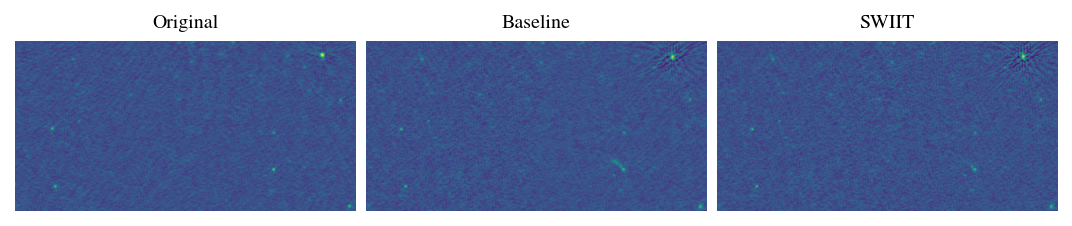

In [36]:
# Example 1: Inconsistent backgroundstructure
originals = scaler.scale(original_imgs[:16, :512, :1024])

idx = 2

plot_grid = np.stack(
    [
        originals[idx],
        samples_baseline[idx],
        samples_swiit[idx],
    ],
    axis=0,
)  # .transpose(1, 0, 2, 3).reshape(-1, *samples_baseline.shape[-2:])
vmin = np.nanmin(plot_grid)
vmax = np.nanmax(plot_grid)

titles = ["Original", "Baseline", "SWIIT"]

fig, axs = plot_image_grid(
    plot_grid,
    n_cols=3,
    figsize=(180 * mm, 60 * mm),
    titles=titles,
    vmin=vmin,
    vmax=vmax,
)

# for img, ax in zip(plot_grid[1:], axs[1:]):
#     add_zoom_inset(
#         fig,
#         ax,
#         img,
#         (256, 512),
#         128,
#         loc="lower right",
#         cmap=None,
#         vmin=vmin,
#         vmax=vmax,
#     )

fig.savefig(
    out_path_sub / f"SWIIT_baseline_example_inconsistent_bg.png",
    **savefig_kw,
)

/tmp/ipykernel_987291/4160727779.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()


/tmp/ipykernel_987291/214935366.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


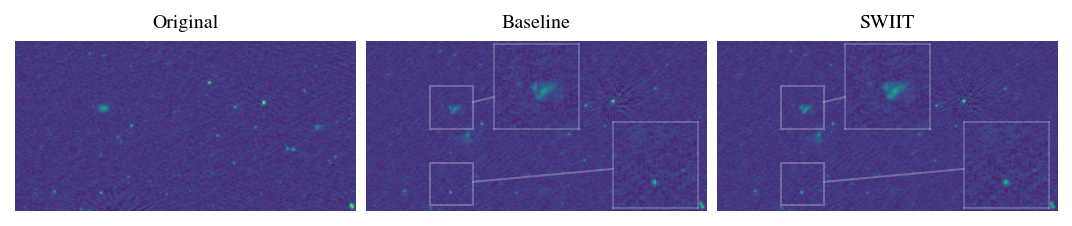

In [38]:
# Example 2: Edge Discontinuity
originals = scaler.scale(original_imgs[:16, :512, :1024])

idx = 4

plot_grid = np.stack(
    [
        originals[idx],
        samples_baseline[idx],
        samples_swiit[idx],
    ],
    axis=0,
)  # .transpose(1, 0, 2, 3).reshape(-1, *samples_baseline.shape[-2:])
vmin = np.nanmin(plot_grid)
vmax = np.nanmax(plot_grid)

titles = ["Original", "Baseline", "SWIIT"]

fig, axs = plot_image_grid(
    plot_grid,
    n_cols=3,
    figsize=(180 * mm, 60 * mm),
    titles=titles,
    vmin=vmin,
    vmax=vmax,
)

for img, ax in zip(plot_grid[1:], axs[1:]):
    add_zoom_inset(
        fig,
        ax,
        img,
        (200, 256),
        128,
        anchor=(0.0, -0.02),
        anchor_corner="upper center",
        cmap=None,
        vmin=vmin,
        vmax=vmax,
    )
    add_zoom_inset(
        fig,
        ax,
        img,
        (430, 256),
        128,
        anchor=(0.1, 0.02),
        anchor_corner="lower right",
        cmap=None,
        vmin=vmin,
        vmax=vmax,
    )

fig.savefig(
    out_path_sub / f"SWIIT_baseline_example_edge_discontinuity.png",
    **savefig_kw,
)

## Power Spectrum

In [ ]:
horiz_acf_baseline = horizontal_autocorr(samples_baseline)
avg_horiz_acf_baseline = horiz_acf_baseline.mean(axis=0)
vert_acf_baseline = vertical_autocorr(samples_baseline)
avg_vert_acf_baseline = vert_acf_baseline.mean(axis=0)

horiz_acf_swiit = horizontal_autocorr(samples_swiit)
avg_horiz_acf_swiit = horiz_acf_swiit.mean(axis=0)
vert_acf_swiit = vertical_autocorr(samples_swiit)
avg_vert_acf_swiit = vert_acf_swiit.mean(axis=0)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_width * 2), sharex=True)

H, W = diff_baseline.shape[-2:]
sl = slice(50, None)
ylim = (-1e-2, 1e-2)
# ylim = (None, None)

indiv_kw = dict(alpha=0.05, lw=0.25)
mean_kw = dict(alpha=1.0, lw=1.0)

color_sampled, color_real = color_samples, color_original

# Horizontal autocorrelation
ax = axs[0]
r = np.arange(W)

for row in horiz_acf_baseline:
    ax.plot(r[sl], row[sl], color=color_sampled, **indiv_kw)
for row in horiz_acf_swiit:
    ax.plot(r[sl], row[sl], color=color_real, **indiv_kw)

ax.plot(
    r[sl],
    horiz_acf_baseline.mean(axis=0)[sl],
    color=color_sampled,
    label="Simple Tiling",
    **mean_kw
)
ax.plot(
    r[sl], horiz_acf_swiit.mean(axis=0)[sl], color=color_real, label="SWIIT", **mean_kw
)

ax.set_ylim(*ylim)
ax.set_ylabel("Horizontal Autocorrelation")

# Vertical autocorrelation
ax = axs[1]
r = np.arange(H)

for row in vert_acf_baseline:
    ax.plot(r[sl], row[sl], color=color_sampled, **indiv_kw)
for row in vert_acf_swiit:
    ax.plot(r[sl], row[sl], color=color_real, **indiv_kw)

ax.plot(
    r[sl],
    vert_acf_baseline.mean(axis=0)[sl],
    color=color_sampled,
    label="Simple Tiling",
    **mean_kw
)
ax.plot(
    r[sl], vert_acf_swiit.mean(axis=0)[sl], color=color_real, label="SWIIT", **mean_kw
)

ax.set_ylim(*ylim)
ax.set_ylabel("Vertical Autocorrelation")
ax.set_xlabel("Pixel Distance")

for ax in axs.flatten():
    label = "Sampling Stride"
    for xval in 256 * np.arange(1, 3):
        ax.axvline(xval, color="grey", linestyle="--", alpha=0.7, lw=1, label=label)
        label = None
    ax.legend(frameon=True, edgecolor="white")

fig.show()

# Size control

In [ ]:
from glori.plotting.utils import auto_log_bins, set_min_counts

title = "Major Axis (arcsec)"
scatter_color = plt.get_cmap("viridis")(0.1)
range_color = plt.get_cmap("viridis")(0.75)
n_bins = 25
min_counts = 25

maj_in = all_inp[2]
maj_out = all_outp[2]
diff = maj_out - maj_in
abs_diff = np.abs(diff)
rel_diff = diff / maj_in
rel_abs_diff = np.abs(rel_diff)
plot_qty = rel_diff

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width * 2 / 3))

# binning for median and 1-sigma:
# Define bins with minimum count
bin_edges = auto_log_bins([maj_in], num=n_bins)
counts, _ = np.histogram(maj_in, bins=bin_edges)
counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))

# Bin input values
digitized = np.digitize(maj_in, bin_edges)
(
    medians,
    medians_inp,
    means,
    sigmas_low,
    sigmas_low_inp,
    sigmas_high,
    sigmas_high_inp,
) = [np.zeros(len(bin_edges) - 1) for _ in range(7)]
for j in range(1, len(bin_edges)):
    bin_vals = plot_qty[digitized == j]
    bin_vals_inp = maj_in[digitized == j]
    if len(bin_vals):
        medians[j - 1] = np.median(bin_vals)
        medians_inp[j - 1] = np.median(bin_vals_inp)
        means[j - 1] = np.mean(bin_vals)
        sigmas_low[j - 1] = np.percentile(bin_vals, 16)
        sigmas_low_inp[j - 1] = np.percentile(bin_vals_inp, 16)
        sigmas_high[j - 1] = np.percentile(bin_vals, 84)
        sigmas_high_inp[j - 1] = np.percentile(bin_vals_inp, 84)

# nonzero_mask = medians > 0
# bin_centers = bin_centers[nonzero_mask]
# medians = medians[nonzero_mask]
# medians_inp = medians_inp[nonzero_mask]
# means = means[nonzero_mask]
# sigmas_low = sigmas_low[nonzero_mask]
# sigmas_low_inp = sigmas_low_inp[nonzero_mask]
# sigmas_high = sigmas_high[nonzero_mask]
# sigmas_high_inp = sigmas_high_inp[nonzero_mask]


# Plot error bars with sigms as yerr and bin edges as xerr
ax.errorbar(
    medians_inp,
    medians,
    yerr=[medians - sigmas_low, sigmas_high - medians],
    xerr=[medians_inp - sigmas_low_inp, sigmas_high_inp - medians_inp],
    fmt="none",
    ecolor=range_color,
    alpha=0.9,
    label="Bin Median",
    linewidth=1,
    capsize=2,
    capthick=0.5,
)

# Plot boxes
ax.stairs(
    sigmas_high,
    bin_edges,
    baseline=sigmas_low,
    color=range_color,
    fill=True,
    alpha=0.2,
    label="Bins",
)

ylim = ax.get_ylim()

# Scatter plot
ax.scatter(
    maj_in,
    plot_qty,
    **(
        dict(
            s=0.5,
            alpha=0.05,
            label="Matched",
            color=scatter_color,
        )
    ),
)

ax.set_ylim(-0.7, 0.7)

# set labels
ax.set_xlabel(title)
ax.set_ylabel("Relative Difference")
# Set axis scales
ax.set_xscale("log")
# ax.set_yscale("log")

# Plot legend
legend = ax.legend(loc="upper right")

# Set alpha for scatter points in the legend to 0.5
for handle, label in zip(legend.legend_handles, legend.get_texts()):
    if label.get_text() == "Matched":
        handle.set_alpha(0.5)

fig.savefig(out_path_sub / "Size_control_relative_difference.png", **savefig_kw)

fig.show()

# Extra detections

## Plot SWIIT Histograms:

In [10]:
from tqdm import tqdm
import pandas as pd

all_unmatched_in = pd.concat([d["unmatched_in"] for d in match_dicts])
all_unmatched_out = pd.concat([d["unmatched_out"] for d in match_dicts])

all_matched_in = pd.concat([d["matched_in"] for d in match_dicts])
all_matched_out = pd.concat([d["matched_out"] for d in match_dicts])

all_input_sources = input_cat
all_detected_sources = pd.concat(srls)

/tmp/ipykernel_987291/1745090179.py:78: RuntimeWarning: invalid value encountered in divide
  purity = np.where(flg_out, c_matched_out / c_out, 0)
/tmp/ipykernel_987291/1745090179.py:59: RuntimeWarning: invalid value encountered in divide
  completeness = np.where(flg_in, c_matched_in / c_in, 0)


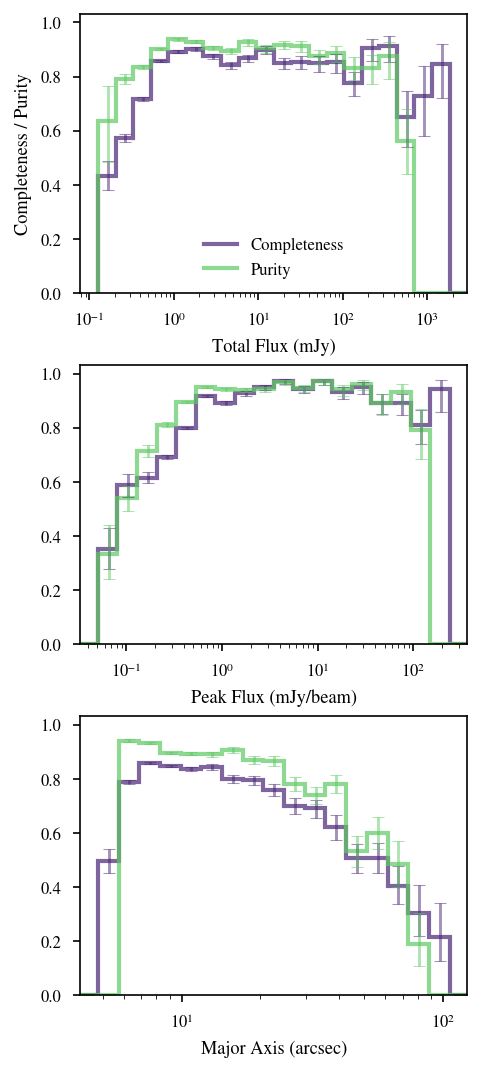

In [ ]:
from astropy.stats import binom_conf_interval
from glori.plotting.utils import auto_log_bins

titles = ["Total Flux (mJy)", "Peak Flux (mJy/beam)", "Major Axis (arcsec)"]
catalog_keys = ["Total_flux", "Peak_flux", "Maj"]
input_color = plt.get_cmap("viridis")(0.1)
output_color = plt.get_cmap("viridis")(0.75)

n_bins = 25
min_counts = 10

fig, axs = plt.subplots(
    1, 3, figsize=(180 * mm, 60 * mm), sharey=True, tight_layout=True
)
for i, title in enumerate(titles):
    ax = axs[i]
    key = catalog_keys[i]

    # binning for median and 1-sigma:
    # Define bins
    bin_edges = auto_log_bins(
        [all_input_sources[key].values, all_detected_sources[key].values], num=n_bins
    )

    # Calculate histograms
    c_in, _ = np.histogram(all_input_sources[key], bins=bin_edges)
    c_out, _ = np.histogram(
        all_detected_sources[key],
        bins=bin_edges,
    )
    c_matched_in, _ = np.histogram(all_matched_in[key], bins=bin_edges)
    c_matched_out, _ = np.histogram(
        all_matched_out[key],
        bins=bin_edges,
    )
    c_unmatched_in, _ = np.histogram(all_unmatched_in[key], bins=bin_edges)
    c_unmatched_out, _ = np.histogram(
        all_unmatched_out[key],
        bins=bin_edges,
    )

    # Flag for min. counts
    flg_in = c_in >= min_counts
    flg_out = c_out >= min_counts

    stairs_kw = dict(
        edges=bin_edges,
        alpha=0.7,
        lw=2,
    )
    errorbar_kw = dict(
        fmt="none",
        alpha=0.5,
        capsize=3,
        capthick=0.5,
    )

    # Plot Completeness
    completeness = np.where(flg_in, c_matched_in / c_in, 0)
    lower, upper = binom_conf_interval(
        np.where(flg_in, c_matched_in, 0),
        np.where(flg_in, c_in, 1),
        confidence_level=0.68269,
        interval="wilson",
    )
    lower = np.where(flg_in, lower, 0)
    upper = np.where(flg_in, upper, 0)
    ax.stairs(completeness, color=input_color, label="Completeness", **stairs_kw)
    ax.errorbar(
        0.5 * (bin_edges[1:] + bin_edges[:-1]),
        completeness,
        yerr=[completeness - lower, upper - completeness],
        color=input_color,
        **errorbar_kw,
    )

    # Plot Purity
    purity = np.where(flg_out, c_matched_out / c_out, 0)
    lower, upper = binom_conf_interval(
        np.where(flg_out, c_matched_out, 0),
        np.where(flg_out, c_out, 1),
        confidence_level=0.68269,
        interval="wilson",
    )
    lower = np.where(flg_out, lower, 0)
    upper = np.where(flg_out, upper, 0)
    ax.stairs(purity, color=output_color, label="Purity", **stairs_kw)
    ax.errorbar(
        0.5 * (bin_edges[1:] + bin_edges[:-1]),
        purity,
        yerr=[purity - lower, upper - purity],
        color=output_color,
        **errorbar_kw,
    )

    # Set axis labels
    ax.set_xlabel(title.replace("_", " "))
    if i == 0:
        ax.set_ylabel("Completeness / Purity")
        ax.legend()

    # Set axis scales
    ax.set_xscale("log")
    # ax.set_yscale("log")

    # Set x limits according to flagged bins
    pad_fraction = 0.05
    # Padding should be equal in log space
    xmin = bin_edges[:-1][flg_in | flg_out].min()
    xmax = bin_edges[1:][flg_in | flg_out].max()

    ax.set_xlim(
        xmin * (xmax / xmin) ** -pad_fraction, xmax * (xmax / xmin) ** pad_fraction
    )

fig.savefig(
    out_path_sub / f"Completeness_Purity_SWIIT.png",
    **savefig_kw,
)

## Load LDM results:

In [39]:
from glori.analysis.ldm.io import load_sampling_result

run_name = "oscillating-crankshaft"

res = load_sampling_result(run_name, missing_is_error=False)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
# wcs = res["wcs"]  # List of WCS objects
wcs = [r['wcs'] for r in res['bdsf_results']]
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

 11:54:42 (glori.analysis.ldm.io) - INFO : Loading results for <oscillating-crankshaft>...
Loading original BDSF results: 100%|██████████| 512/512 [00:11<00:00, 45.61it/s]
 11:55:04 (glori.analysis.ldm.io) - INFO : No input catalogs found.
 11:55:04 (glori.analysis.ldm.io) - INFO : Done.


Source matching:

In [40]:
import glori.analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

 11:55:04 (ldm-match) - INFO : Extracting data from resample result...
 11:55:04 (ldm-match) - INFO : Matching sources...
100%|██████████| 512/512 [00:07<00:00, 66.87it/s]
 11:55:12 (ldm-match) - INFO : Concatenating matched data...
 11:55:12 (ldm-match) - INFO : Done matching sources.

              Total input sources:	20749
             Total output sources:	23400
            Total matched sources:	18038
    Total unmatched input sources:	2711
   Total unmatched output sources:	5171



In [41]:
from tqdm import tqdm
import pandas as pd

all_unmatched_in = pd.concat([d["unmatched_in"] for d in match_dicts])
all_unmatched_out = pd.concat([d["unmatched_out"] for d in match_dicts])

all_matched_in = pd.concat([d["matched_in"] for d in match_dicts])
all_matched_out = pd.concat([d["matched_out"] for d in match_dicts])

all_input_sources = input_cat
all_detected_sources = pd.concat(srls)

In [42]:
def plot_example_pairs_with_unmatched_out(
    sampled_imgs,
    original_imgs,
    match_dicts,
    wcs_list,
    example_idxs=None,
    n_examples=8,
    seed=None,
    marker_kwargs=None,
    titles=("Original", "Sampled"),
    **imshow_kwargs,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from astropy.coordinates import SkyCoord

    def world_to_pixel_2d(wcs_obj, ra_deg, dec_deg):
        from astropy.coordinates import SkyCoord
        import numpy as np

        try:
            pixel = wcs_obj.world_to_pixel_values(ra_deg, dec_deg)
        except Exception:
            if hasattr(wcs_obj, "celestial"):
                pixel = wcs_obj.celestial.world_to_pixel_values(ra_deg, dec_deg)
            else:
                pixel = wcs_obj.world_to_pixel(SkyCoord(ra_deg, dec_deg, unit="deg"))

        pixel = tuple(np.asarray(axis) for axis in pixel)
        return pixel[0], pixel[1]

    if example_idxs is None:
        candidate_idxs = [
            i for i, md in enumerate(match_dicts) if len(md["unmatched_out"]) > 0
        ]
        if not candidate_idxs:
            candidate_idxs = list(range(len(sampled_imgs)))
        if n_examples is not None and len(candidate_idxs) > n_examples:
            rng = np.random.default_rng(seed)
            example_idxs = sorted(
                rng.choice(candidate_idxs, size=n_examples, replace=False).tolist()
            )
        else:
            example_idxs = candidate_idxs[:n_examples]
    else:
        example_idxs = list(example_idxs)

    fig, axs = plt.subplots(
        len(example_idxs),
        2,
        figsize=(20, 10 * len(example_idxs)),
        constrained_layout=True,
    )

    if len(example_idxs) == 1:
        axs = np.array([axs])

    marker_kw = dict(s=120, marker="o", edgecolor="orange", facecolor=None, linewidths=1.5, alpha=0.5)
    if marker_kwargs is not None:
        marker_kw.update(marker_kwargs)

    sampled_imgs = np.asarray(sampled_imgs)
    original_imgs = np.asarray(original_imgs)

    for row, img_idx in enumerate(example_idxs):
        orig_ax = axs[row, 0]
        samp_ax = axs[row, 1]

        orig_ax.imshow(original_imgs[img_idx].squeeze(), **imshow_kwargs)
        samp_ax.imshow(sampled_imgs[img_idx].squeeze(), **imshow_kwargs)

        if row == 0:
            orig_ax.set_title(titles[0])
            samp_ax.set_title(titles[1])

        orig_ax.axis("off")
        samp_ax.axis("off")

        unmatched_out = match_dicts[img_idx]["unmatched_out"]
        if len(unmatched_out):
            coords = SkyCoord(
                unmatched_out["RA"].to_numpy(),
                unmatched_out["DEC"].to_numpy(),
                unit="deg",
            )
            wcs_obj = wcs_list[img_idx]
            x_pix, y_pix = world_to_pixel_2d(wcs_obj, coords.ra.deg, coords.dec.deg)
            samp_ax.scatter(x_pix, y_pix, **marker_kw)

    return fig, axs

In [43]:
# fig, axs = plot_example_pairs_with_unmatched_out(
#     sampled_imgs=sampled_imgs.squeeze(),
#     original_imgs=scaler.scale(original_imgs.reshape(-1, *original_imgs.shape[-2:])),
#     match_dicts=match_dicts,
#     wcs_list=wcs,
#     example_idxs=np.arange(20),
# )

## Plot LDM Histograms:

In [ ]:
from glori.plotting.utils import auto_log_bins, set_min_counts

titles = ["Total Flux (mJy)", "Peak Flux (mJy/beam)", "Major Axis (arcsec)"]
catalog_keys = ["Total_flux", "Peak_flux", "Maj"]
input_color = plt.get_cmap("viridis")(0.1)
output_color = plt.get_cmap("viridis")(0.75)

n_bins = 15
min_counts = 25

fig, axs = plt.subplots(
    1, 3, figsize=(180 * mm, 60 * mm), sharey=True, tight_layout=True
)
for i, title in enumerate(titles):
    ax = axs[i]
    key = catalog_keys[i]

    # binning for median and 1-sigma:
    # Define bins
    bin_edges = auto_log_bins(
        [all_input_sources[key].values, all_detected_sources[key].values], num=n_bins
    )

    # Set axis labels
    ax.set_xlabel(title.replace("_", " "))
    if i == 0:
        ax.set_ylabel("Counts")

    # Plot histograms
    ax.hist(
        all_input_sources[key],
        bins=bin_edges,
        alpha=0.9,
        label="Input Sources",
        color=input_color,
        histtype="step",
    )
    ax.hist(
        all_detected_sources[key],
        bins=bin_edges,
        alpha=0.9,
        label="Detected Sources",
        color=output_color,
        histtype="step",
    )
    ax.hist(
        all_unmatched_in[key],
        bins=bin_edges,
        alpha=0.3,
        label="Unmatched Input Sources",
        color=input_color,
        # hatch="//",
    )
    ax.hist(
        all_unmatched_out[key],
        bins=bin_edges,
        alpha=0.3,
        label="Unmatched Detected Sources",
        color=output_color,
        # hatch="//",
    )

    # Set axis scales
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Plot legend
    legend = ax.legend(loc="upper right")

    # Set alpha for scatter points in the legend to 0.5
    for handle, label in zip(legend.legend_handles, legend.get_texts()):
        if label.get_text() == "Matched":
            handle.set_alpha(0.5)

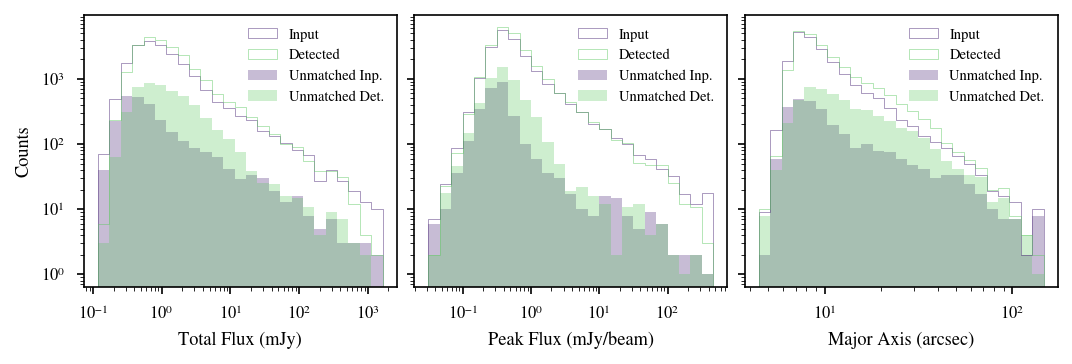

In [45]:
from glori.plotting.utils import auto_log_bins, set_min_counts

titles = ["Total Flux (mJy)", "Peak Flux (mJy/beam)", "Major Axis (arcsec)"]
catalog_keys = ["Total_flux", "Peak_flux", "Maj"]
input_color = plt.get_cmap("viridis")(0.1)
output_color = plt.get_cmap("viridis")(0.75)

n_bins = 25
min_counts = 10

fig, axs = plt.subplots(
    1, 3, figsize=(180 * mm, 60*mm), sharey=True, tight_layout=True
)

for i in [0, 1, 2]:
    ax = axs[i]
    title = titles[i]
    key = catalog_keys[i]

    # binning for median and 1-sigma:
    # Define bins
    bin_edges = auto_log_bins(
        [all_input_sources[key].values, all_detected_sources[key].values], num=n_bins
    )
    counts = (
        np.histogram(all_input_sources[key].values, bins=bin_edges)[0]
        + np.histogram(all_detected_sources[key].values, bins=bin_edges)[0]
    )
    xmin = bin_edges[:-1][counts >= min_counts].min()
    xmax = bin_edges[1:][counts >= min_counts].max()
    bin_edges = np.geomspace(xmin, xmax, n_bins + 1)
    # bin_edges = np.geomspace(1e-1, 2e3, n_bins + 1)

    # Set axis labels
    ax.set_xlabel(title.replace("_", " "))
    if i == 0:
        ax.set_ylabel("Counts")

    # Plot histograms
    ax.hist(
        all_input_sources[key],
        bins=bin_edges,
        alpha=0.9,
        label="Input",
        color=input_color,
        histtype="step",
    )
    ax.hist(
        all_detected_sources[key],
        bins=bin_edges,
        alpha=0.9,
        label="Detected",
        color=output_color,
        histtype="step",
    )
    ax.hist(
        all_unmatched_in[key],
        bins=bin_edges,
        alpha=0.3,
        label="Unmatched Inp.",
        color=input_color,
        # hatch="//",
    )
    ax.hist(
        all_unmatched_out[key],
        bins=bin_edges,
        alpha=0.3,
        label="Unmatched Det.",
        color=output_color,
        # hatch="//",
    )

    # Set axis scales
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Plot legend
    legend = ax.legend(loc="upper right", fontsize=7)

    # Set alpha for scatter points in the legend to 0.5
    for handle, label in zip(legend.legend_handles, legend.get_texts()):
        if label.get_text() == "Matched":
            handle.set_alpha(0.5)

fig.savefig(out_path_sub / "Overdetections_histograms.png", **savefig_kw)

In [ ]:
titles = ["Total Flux (mJy)", "Peak Flux (mJy/beam)", "Major Axis (arcsec)"]
catalog_keys = ["Total_flux", "Peak_flux", "Maj"]
input_color = plt.get_cmap("viridis")(0.1)
output_color = plt.get_cmap("viridis")(0.75)

n_bins = 25
min_counts = 10

fig, axs = plt.subplots(
    1, 3, figsize=(180 * mm, 60 * mm), sharey=True, tight_layout=True
)
for i, title in enumerate(titles):
    ax = axs[i]
    key = catalog_keys[i]

    # binning for median and 1-sigma:
    # Define bins
    bin_edges = auto_log_bins(
        [all_input_sources[key].values, all_detected_sources[key].values], num=n_bins
    )

    # Calculate histograms
    c_in, _ = np.histogram(all_input_sources[key], bins=bin_edges)
    c_out, _ = np.histogram(
        all_detected_sources[key],
        bins=bin_edges,
    )
    c_matched_in, _ = np.histogram(all_matched_in[key], bins=bin_edges)
    c_matched_out, _ = np.histogram(
        all_matched_out[key],
        bins=bin_edges,
    )
    c_unmatched_in, _ = np.histogram(all_unmatched_in[key], bins=bin_edges)
    c_unmatched_out, _ = np.histogram(
        all_unmatched_out[key],
        bins=bin_edges,
    )

    # Flag for min. counts
    flg_in = c_in >= min_counts
    flg_out = c_out >= min_counts

    stairs_kw = dict(
        edges=bin_edges,
        alpha=0.7,
        lw=2,
    )
    errorbar_kw = dict(
        fmt="none",
        alpha=0.5,
        capsize=3,
        capthick=0.5,
    )

    # Plot Completeness
    completeness = np.where(flg_in, c_matched_in / c_in, 0)
    lower, upper = binom_conf_interval(
        np.where(flg_in, c_matched_in, 0),
        np.where(flg_in, c_in, 1),
        confidence_level=0.68269,
        interval="wilson",
    )
    lower = np.where(flg_in, lower, 0)
    upper = np.where(flg_in, upper, 0)
    ax.stairs(completeness, color=input_color, label="Completeness", **stairs_kw)
    ax.errorbar(
        0.5 * (bin_edges[1:] + bin_edges[:-1]),
        completeness,
        yerr=[completeness - lower, upper - completeness],
        color=input_color,
        **errorbar_kw
    )

    # Plot Purity
    purity = np.where(flg_out, c_matched_out / c_out, 0)
    lower, upper = binom_conf_interval(
        np.where(flg_out, c_matched_out, 0),
        np.where(flg_out, c_out, 1),
        confidence_level=0.68269,
        interval="wilson",
    )
    lower = np.where(flg_out, lower, 0)
    upper = np.where(flg_out, upper, 0)
    ax.stairs(purity, color=output_color, label="Purity", **stairs_kw)
    ax.errorbar(
        0.5 * (bin_edges[1:] + bin_edges[:-1]),
        purity,
        yerr=[purity - lower, upper - purity],
        color=output_color,
        **errorbar_kw
    )

    # Set axis labels
    ax.set_xlabel(title.replace("_", " "))
    if i == 0:
        ax.set_ylabel("Completeness / Purity")
        ax.legend()

    # Set axis scales
    ax.set_xscale("log")
    # ax.set_yscale("log")

    # Set x limits according to flagged bins
    pad_fraction = 0.05
    # Padding should be equal in log space
    xmin = bin_edges[:-1][flg_in | flg_out].min()
    xmax = bin_edges[1:][flg_in | flg_out].max()

    ax.set_xlim(
        xmin * (xmax / xmin) ** -pad_fraction, xmax * (xmax / xmin) ** pad_fraction
    )

fig.savefig(out_path_sub / "Completeness_Purity_LDM.png", **savefig_kw)

# Artifacts Examples

## Prepare functions

In [ ]:
# Procedure:

# - Look for the brightest N sources in the sampled SWIIT images
# - Go to position, make cutout of given size centered on source
#   (Unless it is close to edge, then as centered as possible).
#   Do this for both originals and samples, position will be the same
# - Plot side by side

In [ ]:
def topN_indices(arr, N):
    b, h, w = arr.shape
    flat = arr.reshape(-1)

    idx_flat = np.argpartition(flat, -N)[-N:]
    order = np.argsort(-flat[idx_flat])
    idx_flat = idx_flat[order]

    bi, i, j = np.unravel_index(idx_flat, (b, h, w))
    return np.stack([bi, i, j], axis=-1)  # (N, 3)


def make_cutouts(images, positions, cutout_size):
    b, h, w = images.shape
    cutout_h, cutout_w = cutout_size
    cutouts = np.zeros((positions.shape[0], cutout_h, cutout_w), dtype=images.dtype)

    for n in range(positions.shape[0]):
        batch, y, x = positions[n]
        y_min = max(y - cutout_h // 2, 0)
        y_max = min(y + cutout_h // 2 + (cutout_h % 2), h)
        x_min = max(x - cutout_w // 2, 0)
        x_max = min(x + cutout_w // 2 + (cutout_w % 2), w)

        # Adjust if the cutout is smaller than desired size due to edges
        if y_max - y_min < cutout_h:
            if y_min == 0:
                y_max = min(cutout_h, h)
            else:
                y_min = max(h - cutout_h, 0)
                y_max = h

        if x_max - x_min < cutout_w:
            if x_min == 0:
                x_max = min(cutout_w, w)
            else:
                x_min = max(w - cutout_w, 0)
                x_max = w

        cutouts[n] = images[batch, y_min:y_max, x_min:x_max]

    return cutouts

## SWIIT Samples:

In [ ]:
from glori.data.obs.micromaps.utils import expand_context_map

# Bring ctxt map to dimensions of image space
ctxt_expanded = expand_context_map(ctxt, f_upscale=4)  # shape (B, 4, H, W)

# Positions and values of brightest sources in ctxt maps, keeping dimensions
N_brightest = 10
brightest_pos = topN_indices(ctxt_expanded[:, 2], N_brightest)  # shape (B, N, 2)

# Go to position, make cutout of given size centered on source
cutout_size = 512  # pixels
cutouts_samples = make_cutouts(
    sampled_imgs, brightest_pos, (cutout_size, cutout_size)
)  # shape (B, N, C, H_cutout, W_cutout)
cutouts_originals = make_cutouts(
    original_imgs, brightest_pos, (cutout_size, cutout_size)
)  # shape (B, N, C, H_cutout, W_cutout)
cutouts_originals = scaler.scale(cutouts_originals)  # scale originals to [0, 1] range

In [ ]:
n_col = 2
n_examples = N_brightest
example_idxs = np.arange(n_examples)

fig = plt.figure(
    figsize=(180 * mm, (180 * mm / n_col / 2 + 2 * mm) * n_examples / n_col),
    constrained_layout=False,
    dpi=200,
)
outer = fig.add_gridspec(
    n_examples // n_col, n_col, hspace=0.05, wspace=0.05
)  # spacing between pairs

for i, i_example in enumerate(example_idxs):
    inner = outer[i].subgridspec(1, 2, wspace=0.02)  # small gap inside pair
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])

    smpl = cutouts_samples[i_example]
    orig = cutouts_originals[i_example]
    vmin = min(smpl.min(), np.nanmin(orig))
    vmax = max(smpl.max(), np.nanmax(orig))

    im_kw = dict(vmin=vmin, vmax=vmax, cmap="viridis")

    ax1.imshow(orig, **im_kw)
    ax2.imshow(smpl, **im_kw)

    ax1.axis("off")
    ax2.axis("off")

    if i < n_col:
        ax1.set_title("Original")
        ax2.set_title("Sampled")


# fig.show()
fig.canvas.draw()
custom_kw = dict(bbox_inches="tight")
fig.savefig(
    out_path_sub / "Bright_sources_examples_appendix.png", **(savefig_kw | custom_kw)
)

plt.show()

## LDM Samples:

### Load LDM results:

In [ ]:
from glori.analysis.ldm.io import load_sampling_result

run_name = "oscillating-crankshaft"

res = load_sampling_result(run_name, missing_is_error=False)

# Extract data from sweep results
sampled_imgs = res["img_batch"].squeeze()  # Sampled images
original_imgs = res["original_imgs"].reshape(
    -1, *sampled_imgs.shape[-2:]
)  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

Source matching:

In [ ]:
import glori.analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

In [ ]:
from tqdm import tqdm
import pandas as pd

all_unmatched_in = pd.concat([d["unmatched_in"] for d in match_dicts])
all_unmatched_out = pd.concat([d["unmatched_out"] for d in match_dicts])

all_matched_in = pd.concat([d["matched_in"] for d in match_dicts])
all_matched_out = pd.concat([d["matched_out"] for d in match_dicts])

all_input_sources = input_cat
all_detected_sources = pd.concat(srls)

### Find an plot brightest

In [ ]:
ctxt.shape, sampled_imgs.shape

In [ ]:
from glori.data.obs.micromaps.utils import expand_context_map

# Bring ctxt map to dimensions of image space
ctxt_expanded = expand_context_map(ctxt, f_upscale=4)  # shape (B, 4, H, W)

# Positions and values of brightest sources in ctxt maps, keeping dimensions
N_brightest = 10
brightest_pos = topN_indices(ctxt_expanded[:, 2], N_brightest)  # shape (B, N, 2)

# Emulate previous code, but no cutouts, we just take the sampled images
# Go to position, make cutout of given size centered on source
cutouts_samples = sampled_imgs[brightest_pos[:, 0]]
cutouts_originals = original_imgs[brightest_pos[:, 0]]
cutouts_originals = scaler.scale(cutouts_originals)  # scale originals

In [ ]:
n_col = 2
n_examples = N_brightest
example_idxs = np.arange(n_examples)

fig = plt.figure(
    figsize=(180 * mm, (180 * mm / n_col / 2 + 2 * mm) * n_examples / n_col),
    constrained_layout=False,
    dpi=200,
)
outer = fig.add_gridspec(
    n_examples // n_col, n_col, hspace=0.05, wspace=0.05
)  # spacing between pairs

for i, i_example in enumerate(example_idxs):
    inner = outer[i].subgridspec(1, 2, wspace=0.02)  # small gap inside pair
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])

    smpl = cutouts_samples[i_example]
    orig = cutouts_originals[i_example]
    vmin = min(smpl.min(), np.nanmin(orig))
    vmax = max(smpl.max(), np.nanmax(orig))

    im_kw = dict(vmin=vmin, vmax=vmax, cmap="viridis")

    ax1.imshow(orig, **im_kw)
    ax2.imshow(smpl, **im_kw)

    ax1.axis("off")
    ax2.axis("off")

    if i < n_col:
        ax1.set_title("Original")
        ax2.set_title("Sampled")


# fig.show()
fig.canvas.draw()
custom_kw = dict(bbox_inches="tight")
fig.savefig(
    out_path_sub / "Bright_sources_LDM_examples_appendix.png",
    **(savefig_kw | custom_kw)
)

plt.show()